# LASSO — Implementación Manual y Resultados
**Proyecto P1 Optimización · UTEC 2026**
Dataset: Housing Prices Lima, Peru (Urbania)

Implementación de LASSO mediante Descenso por Coordenadas (Coordinate Descent) y Soft-Thresholding, sin depender de rutinas de optimización externas.

In [9]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

sys.path.append('../src')
from preprocessing import get_housing_data
from lasso_manual import LassoManual

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 150,
})
BLUE, GREEN, RED, GRAY = "#2E75B6", "#70AD47", "#C00000", "#595959"

## 1. Carga de datos
Uso del pipeline de preprocesamiento centralizado.

In [10]:
X_train, X_test, y_train, y_test, feature_cols, scaler = get_housing_data(
    "../data/housing_lima_final.xlsx"
)

## 2. Búsqueda de Hiperparámetros (5-Fold CV)

In [11]:
alphas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
best_mse, best_alpha = np.inf, None
cv_results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for a in alphas:
    fold_mses = []
    for train_idx, val_idx in kf.split(X_train):
        Xtr, Xval = X_train[train_idx], X_train[val_idx]
        ytr, yval = y_train[train_idx], y_train[val_idx]
        
        model = LassoManual(alpha=a, max_iter=500, tol=1e-5)
        model.fit(Xtr, ytr)
        fold_mses.append(mean_squared_error(yval, model.predict(Xval)))
        
    mean_mse = np.mean(fold_mses)
    cv_results.append({"alpha": a, "cv_mse": mean_mse})
    
    if mean_mse < best_mse:
        best_mse, best_alpha = mean_mse, a

print(f"Mejor alpha:  {best_alpha}")
print(f"Mejor CV-MSE: {best_mse:.6f}")
pd.DataFrame(cv_results).sort_values("cv_mse").head()

Mejor alpha:  0.001
Mejor CV-MSE: 0.134687


,alpha,cv_mse
0,0.001,0.134687
1,0.005,0.136293
2,0.010,0.140649
3,0.050,0.176454
4,0.100,0.215510


### 3. Entrenamiento Final y Evaluación
Entrenamos el modelo definitivo con el mejor $\lambda$ encontrado.

In [13]:
model_scratch = LassoManual(alpha=best_alpha, max_iter=2000, tol=1e-7)
model_scratch.fit(X_train, y_train)

y_pred_train = model_scratch.predict(X_train)
y_pred_test  = model_scratch.predict(X_test)

mse_train  = mean_squared_error(y_train, y_pred_train)
mse_test   = mean_squared_error(y_test,  y_pred_test)
mae_test   = mean_absolute_error(y_test, y_pred_test)
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)
rmse_test  = np.sqrt(mse_test)
n_zeros    = np.sum(model_scratch.coef_ == 0)
n_nonzero  = np.sum(model_scratch.coef_ != 0)

print(f"Iteraciones hasta convergencia: {model_scratch.n_iter_}")
print(f"Coeficientes en cero (anulados): {n_zeros} / {len(feature_cols)}")
print(f"Coeficientes activos:            {n_nonzero} / {len(feature_cols)}\n")
print(f"{'Métrica':<15} {'Train':>10} {'Test':>10}")
print("-" * 38)
print(f"{'R²':<15} {r2_train:>10.4f} {r2_test:>10.4f}")
print(f"{'RMSE':<15} {np.sqrt(mse_train):>10.4f} {rmse_test:>10.4f}")

Iteraciones hasta convergencia: 105
Coeficientes en cero (anulados): 9 / 70
Coeficientes activos:            61 / 70

Métrica              Train       Test
--------------------------------------
R²                  0.8013     0.7713
RMSE                0.3622     0.4009


### 4. Validación contra Scikit-Learn
Comparamos nuestra implementación manual contra la librería optimizada de la industria. *Nota: Scikit-learn llama `alpha` a nuestro parámetro `lambda`.*

In [7]:
model_sklearn = Lasso(alpha=best_alpha, max_iter=10000, tol=1e-8)
model_sklearn.fit(X_train, y_train)

y_pred_sk = model_sklearn.predict(X_test)
r2_sk     = r2_score(y_test, y_pred_sk)
mse_sk    = mean_squared_error(y_test, y_pred_sk)

max_coef_diff = np.max(np.abs(model_scratch.coef_ - model_sklearn.coef_))

print(f"{'Métrica':<20} {'Scratch':>12} {'Sklearn':>12} {'Diferencia':>12}")
print("-" * 58)
print(f"{'R² Test':<20} {r2_test:>12.6f} {r2_sk:>12.6f} {abs(r2_test-r2_sk):>12.2e}")
print(f"{'MSE Test':<20} {mse_test:>12.6f} {mse_sk:>12.6f} {abs(mse_test-mse_sk):>12.2e}")
print(f"{'Max Diff Coef':<20} {'-':>12} {'-':>12} {max_coef_diff:>12.2e}")

Métrica                   Scratch      Sklearn   Diferencia
----------------------------------------------------------
R² Test                  0.771330     0.771330     5.94e-08
MSE Test                 0.160685     0.160685     4.17e-08
Max Diff Coef                   -            -     5.50e-07


### 5. Regularization Path y Gráficas
Visualizamos geométricamente cómo la penalización $L_1$ fuerza a los coeficientes a colapsar exactamente a cero.

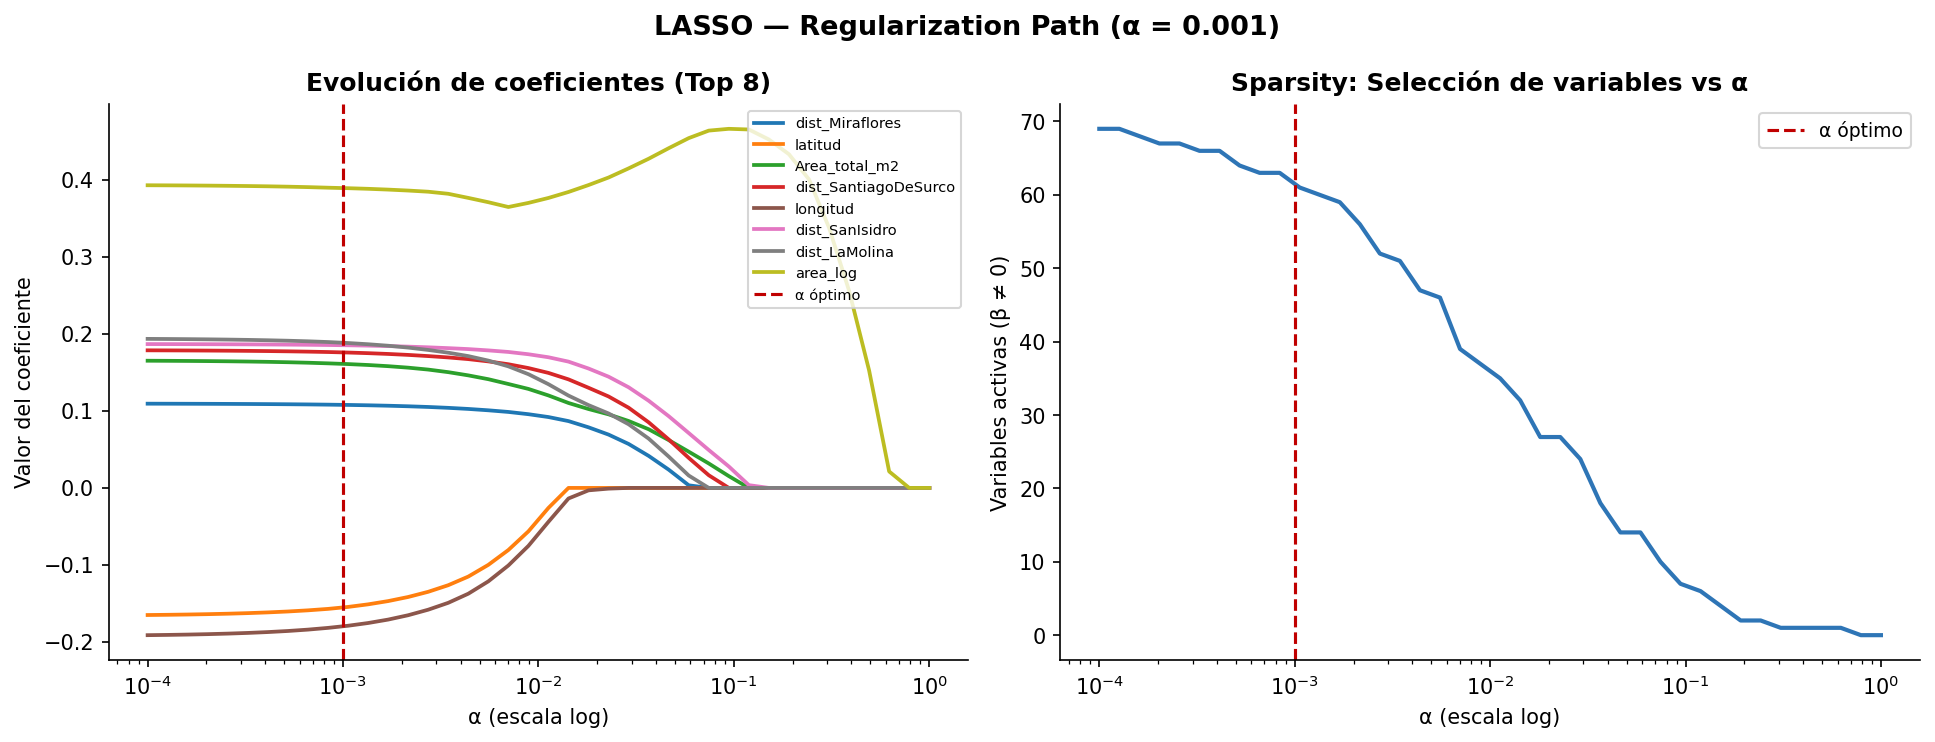

In [14]:
alphas_path = np.logspace(-4, 0, 40)
coef_path = []

for a in alphas_path:
    m = LassoManual(alpha=a, max_iter=500, tol=1e-5)
    m.fit(X_train, y_train)
    coef_path.append(m.coef_.copy())

coef_path = np.array(coef_path)
opt_idx = np.argmin(np.abs(alphas_path - best_alpha))
top_idx = np.argsort(np.abs(coef_path[opt_idx]))[-8:]
top_names = [feature_cols[i] for i in top_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"LASSO — Regularization Path (α = {best_alpha})", fontsize=13, fontweight="bold")

ax = axes[0]
cmap = plt.cm.tab10
for i, (idx, name) in enumerate(zip(top_idx, top_names)):
    ax.plot(alphas_path, coef_path[:, idx], label=name, color=cmap(i/8), linewidth=1.8)
ax.axvline(best_alpha, color=RED, linestyle="--", linewidth=1.5, label="α óptimo")
ax.set_xscale("log")
ax.set_xlabel("α (escala log)")
ax.set_ylabel("Valor del coeficiente")
ax.set_title("Evolución de coeficientes (Top 8)")
ax.legend(fontsize=7, loc="upper right")

ax = axes[1]
n_active = [np.sum(coef_path[i] != 0) for i in range(len(alphas_path))]
ax.plot(alphas_path, n_active, color=BLUE, linewidth=2)
ax.axvline(best_alpha, color=RED, linestyle="--", linewidth=1.5, label="α óptimo")
ax.set_xscale("log")
ax.set_xlabel("α (escala log)")
ax.set_ylabel("Variables activas (β ≠ 0)")
ax.set_title("Sparsity: Selección de variables vs α")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

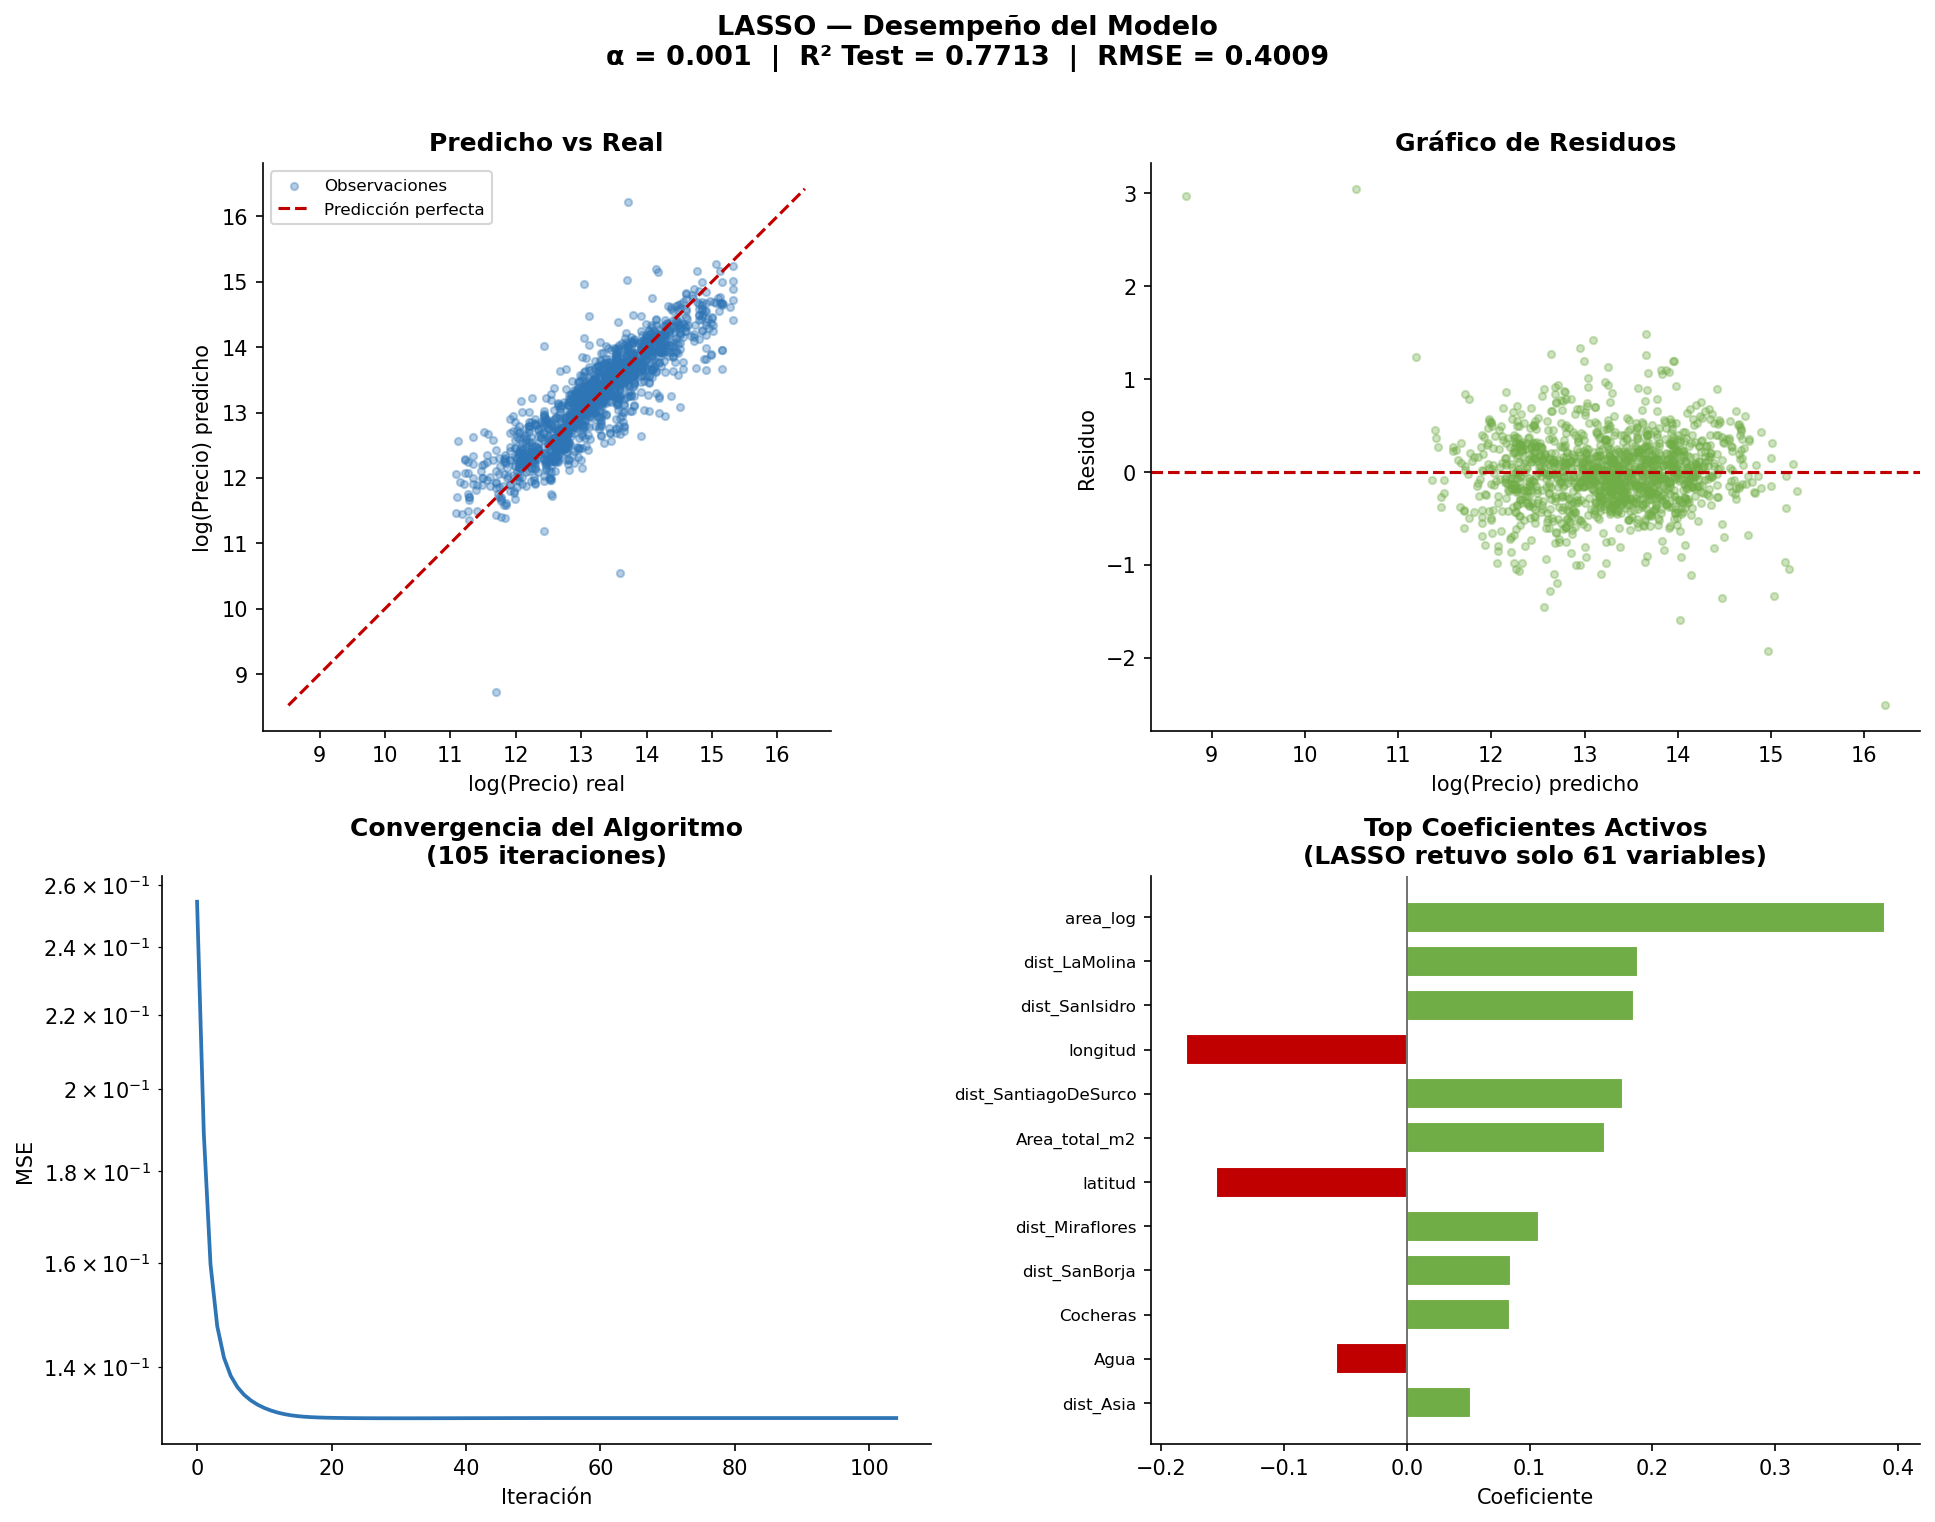

In [15]:
# ── Cuadrícula de Resultados Principales (LASSO) ──
fig_res, axes_res = plt.subplots(2, 2, figsize=(13, 10))
fig_res.suptitle(
    f"LASSO — Desempeño del Modelo\n"
    f"α = {best_alpha}  |  R² Test = {r2_test:.4f}  |  RMSE = {rmse_test:.4f}",
    fontsize=13, fontweight="bold", y=1.01
)

# 1. Predicho vs Real
ax = axes_res[0, 0]
ax.scatter(y_test, y_pred_test, alpha=0.35, s=12, color=BLUE, label="Observaciones")
lims = [min(y_test.min(), y_pred_test.min()) - 0.2, max(y_test.max(), y_pred_test.max()) + 0.2]
ax.plot(lims, lims, "--", color=RED, linewidth=1.5, label="Predicción perfecta")
ax.set_xlabel("log(Precio) real")
ax.set_ylabel("log(Precio) predicho")
ax.set_title("Predicho vs Real")
ax.legend(fontsize=8)
ax.set_aspect("equal")

# 2. Residuos
ax = axes_res[0, 1]
residuos = y_test - y_pred_test
ax.scatter(y_pred_test, residuos, alpha=0.35, s=12, color=GREEN)
ax.axhline(0, color=RED, linewidth=1.5, linestyle="--")
ax.set_xlabel("log(Precio) predicho")
ax.set_ylabel("Residuo")
ax.set_title("Gráfico de Residuos")

# 3. Convergencia
ax = axes_res[1, 0]
ax.plot(model_scratch.loss_history_, color=BLUE, linewidth=1.8)
ax.set_xlabel("Iteración")
ax.set_ylabel("MSE")
ax.set_title(f"Convergencia del Algoritmo\n({model_scratch.n_iter_} iteraciones)")
ax.set_yscale("log")

# 4. Top Coeficientes
ax = axes_res[1, 1]
coef_df = pd.DataFrame({"Variable": feature_cols, "Coef": model_scratch.coef_})
coef_df["Abs"] = np.abs(coef_df["Coef"])
# Filtramos los ceros y agarramos los top
top_plot = coef_df[coef_df["Coef"] != 0].sort_values("Abs", ascending=False).head(12)
colors_bar = [GREEN if c > 0 else RED for c in top_plot["Coef"]]
ax.barh(range(len(top_plot)), top_plot["Coef"], color=colors_bar, edgecolor="white", height=0.7)
ax.set_yticks(range(len(top_plot)))
ax.set_yticklabels(top_plot["Variable"], fontsize=8)
ax.axvline(0, color=GRAY, linewidth=0.8)
ax.set_xlabel("Coeficiente")
ax.set_title(f"Top Coeficientes Activos\n(LASSO retuvo solo {n_nonzero} variables)")
ax.invert_yaxis()

plt.tight_layout()
plt.show()